In [1]:
from google.colab import files

uploaded = files.upload()

Saving sample_-_superstore.xls to sample_-_superstore.xls


In [2]:
import pandas as pd

df = pd.read_excel("sample_-_superstore.xls")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10194, 21)


In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

In [5]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [6]:
sales_df = df.copy()

# Remove duplicate rows
sales_df = sales_df.drop_duplicates()

# Make sure date columns are in datetime format
sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"])
sales_df["Ship Date"] = pd.to_datetime(sales_df["Ship Date"])

# Check the result
print("Rows after cleaning:", len(sales_df))
print("Duplicate rows:", sales_df.duplicated().sum())
print("Missing values:", sales_df.isnull().sum().sum())

Rows after cleaning: 10194
Duplicate rows: 0
Missing values: 0


In [7]:
total_sales = sales_df["Sales"].sum()
total_profit = sales_df["Profit"].sum()
total_quantity = sales_df["Quantity"].sum()
total_orders = sales_df["Order ID"].nunique()

average_order_value = total_sales / total_orders
profit_margin = (total_profit / total_sales) * 100

print("SMARTSALES AI - BUSINESS KPIs")
print("-" * 35)

print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Profit      : ${total_profit:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Quantity    : {total_quantity:,}")
print(f"Average Order     : ${average_order_value:,.2f}")
print(f"Profit Margin     : {profit_margin:.2f}%")

SMARTSALES AI - BUSINESS KPIs
-----------------------------------
Total Sales       : $2,326,534.35
Total Profit      : $292,296.81
Total Orders      : 5,111
Total Quantity    : 38,654
Average Order     : $455.20
Profit Margin     : 12.56%


In [8]:
category_sales = sales_df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).sort_values("Sales", ascending=False)

category_sales

,Sales,Profit,Quantity
Category,,,
Technology,839893.2790,146543.3756,7017
Furniture,754747.7613,19729.9956,8369
Office Supplies,731893.3140,126023.4434,23268


In [9]:
region_sales = sales_df.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
).sort_values("Sales", ascending=False)

region_sales

,Sales,Profit,Orders
Region,,,
West,739813.6085,110798.8170,1635
East,691828.1680,94883.2603,1475
Central,503170.6728,39865.3070,1179
South,391721.9050,46749.4303,822


In [10]:
top_products = sales_df.groupby("Product Name").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).sort_values("Sales", ascending=False).head(10)

top_products

,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03,31
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03,6
HON 5400 Series Task Chairs for Big and Tall,21870.576,3.410605e-13,39
GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48
Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03,12
GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27


In [12]:
import plotly.express as px

In [13]:
category_sales = sales_df.groupby("Category", as_index=False).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

fig = px.bar(
    category_sales,
    x="Category",
    y="Sales",
    title="Sales by Category",
    text_auto=".2s"
)

fig.show()

In [14]:
region_sales = sales_df.groupby("Region", as_index=False).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

fig = px.bar(
    region_sales,
    x="Region",
    y="Sales",
    title="Sales by Region",
    text_auto=".2s"
)

fig.show()

In [15]:
monthly_sales = (
    sales_df
    .set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
    .reset_index()
)

fig = px.line(
    monthly_sales,
    x="Order Date",
    y="Sales",
    markers=True,
    title="Monthly Sales Trend"
)

fig.show()

In [16]:
loss_products = (
    sales_df.groupby("Product Name")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
    .sort_values("Profit")
)

loss_products.head(10)

,Sales,Profit,Quantity
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22
Balt Solid Wood Round Tables,6518.754,-1201.0581,19


In [17]:
fig = px.scatter(
    sales_df,
    x="Discount",
    y="Profit",
    size="Sales",
    hover_data=["Category", "Sub-Category"],
    title="Discount vs Profit"
)

fig.show()

In [18]:
import pandas as pd
import numpy as np

# Use the latest order date as the reference date
reference_date = sales_df["Order Date"].max() + pd.Timedelta(days=1)

rfm = sales_df.groupby("Customer ID").agg(
    Recency=("Order Date", lambda x: (reference_date - x.max()).days),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales", "sum")
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156


In [19]:
rfm.describe()

,Recency,Frequency,Monetary
count,804.000000,804.000000,804.000000
mean,147.016169,6.364428,2893.699446
std,185.551511,2.660121,2653.778471
min,1.000000,1.000000,4.833000
25%,30.000000,5.000000,1084.538000
50%,76.000000,6.000000,2243.392000
75%,181.750000,8.000000,3790.812100
max,1166.000000,17.000000,25043.050000


In [20]:
from sklearn.preprocessing import StandardScaler

features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[features])

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=features
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,0.204835,-0.513239,1.006686
1,-0.684959,0.991388,-0.692768
2,0.609287,-0.889396,-0.415963
3,-0.490822,-0.137082,0.826972
4,1.450547,-1.265552,-0.756956


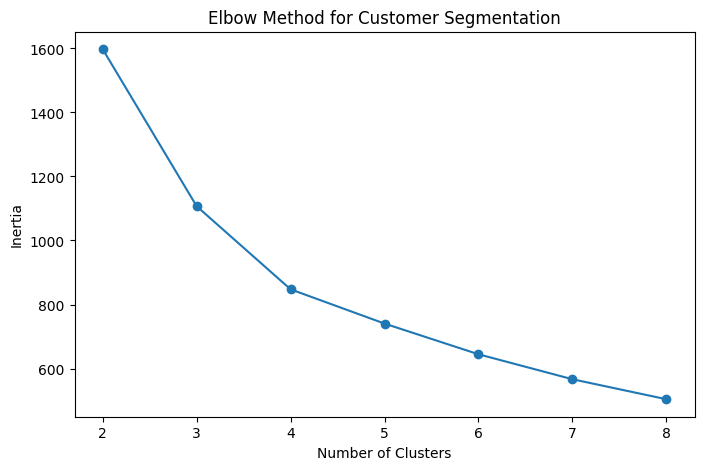

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 9),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Customer Segmentation")

plt.show()

In [22]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,AA-10315,185,5,5563.560,0
1,AA-10375,20,9,1056.390,3
2,AA-10480,260,4,1790.512,0
3,AA-10645,56,6,5086.935,3
4,AB-10015,416,3,886.156,1


In [23]:
cluster_summary = rfm.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,340,98.67,4.71,1615.68
1,103,546.15,3.84,1585.02
2,67,113.88,8.58,9449.93
3,294,70.65,8.66,3336.06


In [24]:
cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,340,98.67,4.71,1615.68
1,103,546.15,3.84,1585.02
2,67,113.88,8.58,9449.93
3,294,70.65,8.66,3336.06


In [25]:
cluster_names = {
    0: "Regular Customers",
    1: "Inactive Customers",
    2: "High-Value Customers",
    3: "Frequent Customers"
}

rfm["Customer Segment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Customer Segment
0,AA-10315,185,5,5563.560,0,Regular Customers
1,AA-10375,20,9,1056.390,3,Frequent Customers
2,AA-10480,260,4,1790.512,0,Regular Customers
3,AA-10645,56,6,5086.935,3,Frequent Customers
4,AB-10015,416,3,886.156,1,Inactive Customers


In [26]:
fig = px.scatter(
    rfm,
    x="Frequency",
    y="Monetary",
    color="Customer Segment",
    size="Monetary",
    hover_data=["Customer ID", "Recency"],
    title="AI-Based Customer Segmentation",
    labels={
        "Frequency": "Number of Orders",
        "Monetary": "Total Customer Spending"
    }
)

fig.show()

In [27]:
segment_summary = rfm.groupby("Customer Segment").agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Spending=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
).round(2)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Spending,Total_Revenue
Customer Segment,,,,,
Frequent Customers,294,70.65,8.66,3336.06,980800.86
High-Value Customers,67,113.88,8.58,9449.93,633145.34
Inactive Customers,103,546.15,3.84,1585.02,163256.71
Regular Customers,340,98.67,4.71,1615.68,549331.44


In [28]:
segment_summary = rfm.groupby("Customer Segment").agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Spending=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
).round(2)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Spending,Total_Revenue
Customer Segment,,,,,
Frequent Customers,294,70.65,8.66,3336.06,980800.86
High-Value Customers,67,113.88,8.58,9449.93,633145.34
Inactive Customers,103,546.15,3.84,1585.02,163256.71
Regular Customers,340,98.67,4.71,1615.68,549331.44


In [29]:
monthly_sales.head()

,Order Date,Sales
0,2023-01-31,14518.055
1,2023-02-28,4519.892
2,2023-03-31,56933.909
3,2023-04-30,28295.345
4,2023-05-31,26319.767


In [30]:
monthly_sales.tail()

,Order Date,Sales
43,2026-08-31,64129.7580
44,2026-09-30,88064.5320
45,2026-10-31,83474.7832
46,2026-11-30,118454.5050
47,2026-12-31,85175.0328


In [31]:
print("Number of months:", len(monthly_sales))

Number of months: 48


In [32]:
forecast_df = monthly_sales.copy()

forecast_df["Month"] = forecast_df["Order Date"].dt.month
forecast_df["Year"] = forecast_df["Order Date"].dt.year

forecast_df["Time_Index"] = range(len(forecast_df))

forecast_df["Lag_1"] = forecast_df["Sales"].shift(1)
forecast_df["Lag_2"] = forecast_df["Sales"].shift(2)
forecast_df["Lag_3"] = forecast_df["Sales"].shift(3)

forecast_df["Rolling_3"] = (
    forecast_df["Sales"]
    .rolling(3)
    .mean()
)

forecast_df.head(10)

,Order Date,Sales,Month,Year,Time_Index,Lag_1,Lag_2,Lag_3,Rolling_3
0,2023-01-31,14518.0550,1,2023,0,NaN,NaN,NaN,NaN
1,2023-02-28,4519.8920,2,2023,1,14518.0550,NaN,NaN,NaN
2,2023-03-31,56933.9090,3,2023,2,4519.8920,14518.0550,NaN,25323.952000
3,2023-04-30,28295.3450,4,2023,3,56933.9090,4519.8920,14518.0550,29916.382000
4,2023-05-31,26319.7670,5,2023,4,28295.3450,56933.9090,4519.8920,37183.007000
5,2023-06-30,34669.4796,6,2023,5,26319.7670,28295.3450,56933.9090,29761.530533
6,2023-07-31,33946.3930,7,2023,6,34669.4796,26319.7670,28295.3450,31645.213200
7,2023-08-31,28918.3385,8,2023,7,33946.3930,34669.4796,26319.7670,32511.403700
8,2023-09-30,82670.4288,9,2023,8,28918.3385,33946.3930,34669.4796,48511.720100
9,2023-10-31,32413.3390,10,2023,9,82670.4288,28918.3385,33946.3930,48000.702100


In [33]:
forecast_df = forecast_df.dropna().reset_index(drop=True)

print("Rows available for modeling:", len(forecast_df))

Rows available for modeling: 45


In [34]:
split_point = int(len(forecast_df) * 0.8)

train = forecast_df.iloc[:split_point]
test = forecast_df.iloc[split_point:]

print("Training months:", len(train))
print("Testing months:", len(test))

Training months: 36
Testing months: 9


In [35]:
from sklearn.ensemble import RandomForestRegressor

features = [
    "Month",
    "Year",
    "Time_Index",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_3"
]

X_train = train[features]
y_train = train["Sales"]

X_test = test[features]
y_test = test["Sales"]

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=10
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

mape = np.mean(
    np.abs((y_test - predictions) / y_test)
) * 100

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : $12,163.97
RMSE : $16,104.78
MAPE : 15.97%


In [38]:
import plotly.graph_objects as go

In [39]:
comparison = test[["Order Date", "Sales"]].copy()

comparison["Predicted Sales"] = predictions

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=comparison["Order Date"],
        y=comparison["Sales"],
        mode="lines+markers",
        name="Actual Sales"
    )
)

fig.add_trace(
    go.Scatter(
        x=comparison["Order Date"],
        y=comparison["Predicted Sales"],
        mode="lines+markers",
        name="Predicted Sales"
    )
)

fig.update_layout(
    title="Actual vs Predicted Monthly Sales",
    xaxis_title="Date",
    yaxis_title="Sales"
)

fig.show()

In [42]:
from sklearn.ensemble import IsolationForest

anomaly_data = sales_df[
    ["Sales", "Quantity", "Discount", "Profit"]
].copy()

iso_model = IsolationForest(
    contamination=0.02,
    random_state=42
)

sales_df["Anomaly_Flag"] = iso_model.fit_predict(anomaly_data)

sales_df["Anomaly"] = sales_df["Anomaly_Flag"].map({
    1: "Normal",
    -1: "Anomaly"
})

print("Total transactions:", len(sales_df))
print("Anomalies detected:", (sales_df["Anomaly"] == "Anomaly").sum())

Total transactions: 10194
Anomalies detected: 204


In [43]:
anomalies = sales_df[
    sales_df["Anomaly"] == "Anomaly"
].copy()

anomalies[
    [
        "Order ID",
        "Product Name",
        "Category",
        "Sales",
        "Quantity",
        "Discount",
        "Profit"
    ]
].head(20)

,Order ID,Product Name,Category,Sales,Quantity,Discount,Profit
5,US-2023-167199,Global Deluxe High-Back Manager's Chair,Furniture,2573.820,9,0.0,746.4078
146,US-2023-130421,3.6 Cubic Foot Counter Height Office Refrigerator,Office Supplies,176.772,3,0.8,-459.6072
199,US-2023-148838,Bretford Rectangular Conference Table Tops,Furniture,1579.746,7,0.4,-447.5947
226,US-2023-145317,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,6,0.5,-1811.0784
245,US-2023-163223,Samsung Galaxy S4 Active,Technology,3499.930,7,0.0,909.9818
321,US-2023-102988,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,4164.050,5,0.0,83.2810
364,US-2023-122336,Fellowes PB200 Plastic Comb Binding Machine,Office Supplies,509.970,10,0.7,-407.9760
471,US-2023-119172,Avery Arch Ring Binders,Office Supplies,104.580,9,0.8,-172.5570
479,US-2023-140165,GBC DocuBind P100 Manual Binding Machine,Office Supplies,398.352,8,0.7,-331.9600
509,US-2023-117639,Fellowes PB300 Plastic Comb Binding Machine,Office Supplies,2715.930,7,0.0,1276.4871


In [44]:
fig = px.scatter(
    sales_df,
    x="Sales",
    y="Profit",
    color="Anomaly",
    size="Quantity",
    hover_data=[
        "Order ID",
        "Product Name",
        "Category",
        "Discount"
    ],
    title="Anomaly Detection: Sales vs Profit"
)

fig.show()

In [45]:
business_summary = {
    "total_sales": sales_df["Sales"].sum(),
    "total_profit": sales_df["Profit"].sum(),
    "total_orders": sales_df["Order ID"].nunique(),
    "profit_margin": (
        sales_df["Profit"].sum() /
        sales_df["Sales"].sum()
    ) * 100,
    "top_category": category_sales.loc[
        category_sales["Sales"].idxmax(),
        "Category"
    ],
    "top_region": region_sales.loc[
        region_sales["Sales"].idxmax(),
        "Region"
    ],
    "anomalies": len(anomalies),
    "high_value_customers": (
        rfm["Customer Segment"] == "High-Value Customers"
    ).sum()
}

business_summary

{'total_sales': np.float64(2326534.3543),
 'total_profit': np.float64(292296.8145999999),
 'total_orders': 5111,
 'profit_margin': np.float64(12.563614805849074),
 'top_category': 'Technology',
 'top_region': 'West',
 'anomalies': 204,
 'high_value_customers': np.int64(67)}

In [46]:
print("========== BUSINESS INSIGHTS ==========\n")

print(
    f"Total Sales: ${business_summary['total_sales']:,.2f}"
)

print(
    f"Total Profit: ${business_summary['total_profit']:,.2f}"
)

print(
    f"Profit Margin: {business_summary['profit_margin']:.2f}%"
)

print(
    f"Total Orders: {business_summary['total_orders']:,}"
)

print(
    f"Top Category: {business_summary['top_category']}"
)

print(
    f"Top Region: {business_summary['top_region']}"
)

print(
    f"High-Value Customers: "
    f"{business_summary['high_value_customers']}"
)

print(
    f"Potential Anomalies: "
    f"{business_summary['anomalies']}"
)

========== BUSINESS INSIGHTS ==========

Total Sales: $2,326,534.35
Total Profit: $292,296.81
Profit Margin: 12.56%
Total Orders: 5,111
Top Category: Technology
Top Region: West
High-Value Customers: 67
Potential Anomalies: 204


In [47]:
def generate_insights(summary):

    insights = []

    # Sales insight
    insights.append(
        f"The business generated ${summary['total_sales']:,.2f} "
        f"in total sales across {summary['total_orders']:,} orders."
    )

    # Profit insight
    insights.append(
        f"The overall profit was ${summary['total_profit']:,.2f}, "
        f"resulting in a profit margin of "
        f"{summary['profit_margin']:.2f}%."
    )

    # Category insight
    insights.append(
        f"{summary['top_category']} is the highest-performing "
        f"category based on total sales."
    )

    # Region insight
    insights.append(
        f"{summary['top_region']} is the leading region "
        f"based on sales."
    )

    # Customer insight
    insights.append(
        f"The analysis identified {summary['high_value_customers']} "
        f"high-value customers who may be important for "
        f"customer retention strategies."
    )

    # Anomaly insight
    insights.append(
        f"The anomaly detection model identified "
        f"{summary['anomalies']} potentially unusual transactions "
        f"that may require further investigation."
    )

    return insights

In [48]:
insights = generate_insights(business_summary)

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

1. The business generated $2,326,534.35 in total sales across 5,111 orders.
2. The overall profit was $292,296.81, resulting in a profit margin of 12.56%.
3. Technology is the highest-performing category based on total sales.
4. West is the leading region based on sales.
5. The analysis identified 67 high-value customers who may be important for customer retention strategies.
6. The anomaly detection model identified 204 potentially unusual transactions that may require further investigation.


In [49]:
ai_context = f"""
You are a business data analyst.

Analyze the following Superstore business data.

Total Sales: ${business_summary['total_sales']:,.2f}
Total Profit: ${business_summary['total_profit']:,.2f}
Profit Margin: {business_summary['profit_margin']:.2f}%
Total Orders: {business_summary['total_orders']:,}

Top Category: {business_summary['top_category']}
Top Region: {business_summary['top_region']}

High-Value Customers: {business_summary['high_value_customers']}
Potential Anomalies: {business_summary['anomalies']}

Forecasting Model:
MAE: ${mae:,.2f}
RMSE: ${rmse:,.2f}
MAPE: {mape:.2f}%

Customer Segments:
{cluster_summary.to_string()}

Provide:
1. Overall business performance
2. Customer insights
3. Sales insights
4. Potential risks
5. Actionable business recommendations

Do not invent information that is not present in the data.
"""

print(ai_context)


You are a business data analyst.

Analyze the following Superstore business data.

Total Sales: $2,326,534.35
Total Profit: $292,296.81
Profit Margin: 12.56%
Total Orders: 5,111

Top Category: Technology
Top Region: West

High-Value Customers: 67
Potential Anomalies: 204

Forecasting Model:
MAE: $12,163.97
RMSE: $16,104.78
MAPE: 15.97%

Customer Segments:
         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                     
0              340        98.67           4.71       1615.68
1              103       546.15           3.84       1585.02
2               67       113.88           8.58       9449.93
3              294        70.65           8.66       3336.06

Provide:
1. Overall business performance
2. Customer insights
3. Sales insights
4. Potential risks
5. Actionable business recommendations

Do not invent information that is not present in the data.



In [50]:
import plotly.express as px

corr = sales_df[["Sales", "Quantity", "Discount", "Profit"]].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    title="Correlation Between Sales, Profit, Discount and Quantity"
)

fig.show()

In [51]:
monthly_sales = sales_df.groupby(
    sales_df["Order Date"].dt.to_period("M")
)["Sales"].sum().reset_index()

monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)

fig = px.line(
    monthly_sales,
    x="Order Date",
    y="Sales",
    markers=True,
    title="Monthly Sales Trend"
)

fig.show()

In [52]:
category_profit = sales_df.groupby("Category")["Profit"].sum().reset_index()

fig = px.bar(
    category_profit,
    x="Category",
    y="Profit",
    title="Profit by Category",
    text_auto=".2s"
)

fig.show()

In [53]:
fig = px.scatter(
    sales_df,
    x="Discount",
    y="Profit",
    size="Sales",
    color="Category",
    hover_data=["Product Name"],
    title="Impact of Discount on Profit"
)

fig.show()

In [54]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# -----------------------------
# Prepare data
# -----------------------------

sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"])

total_sales = sales_df["Sales"].sum()
total_profit = sales_df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100
total_orders = sales_df["Order ID"].nunique()

category_data = sales_df.groupby("Category", as_index=False).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

region_data = sales_df.groupby("Region", as_index=False).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

monthly_data = (
    sales_df
    .set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
    .reset_index()
)

# -----------------------------
# Create dashboard
# -----------------------------

fig = make_subplots(
    rows=4,
    cols=2,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}],
        [{"type": "indicator"}, {"type": "indicator"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}]
    ],
    subplot_titles=(
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Total Orders",
        "Monthly Sales Trend",
        "Sales by Category",
        "Profit by Region",
        "Discount vs Profit"
    ),
    vertical_spacing=0.10,
    horizontal_spacing=0.08
)

# -----------------------------
# KPI 1 - Sales
# -----------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_sales,
        number={"prefix": "$", "valueformat": ",.0f"}
    ),
    row=1, col=1
)

# -----------------------------
# KPI 2 - Profit
# -----------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_profit,
        number={"prefix": "$", "valueformat": ",.0f"}
    ),
    row=1, col=2
)

# -----------------------------
# KPI 3 - Profit Margin
# -----------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=profit_margin,
        number={"suffix": "%", "valueformat": ".2f"}
    ),
    row=2, col=1
)

# -----------------------------
# KPI 4 - Orders
# -----------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_orders,
        number={"valueformat": ",.0f"}
    ),
    row=2, col=2
)

# -----------------------------
# Monthly Sales
# -----------------------------

fig.add_trace(
    go.Scatter(
        x=monthly_data["Order Date"],
        y=monthly_data["Sales"],
        mode="lines+markers",
        name="Monthly Sales"
    ),
    row=3, col=1
)

# -----------------------------
# Sales by Category
# -----------------------------

fig.add_trace(
    go.Bar(
        x=category_data["Category"],
        y=category_data["Sales"],
        text=category_data["Sales"],
        texttemplate="$%{text:,.0f}",
        textposition="outside",
        name="Category Sales"
    ),
    row=3, col=2
)

# -----------------------------
# Profit by Region
# -----------------------------

fig.add_trace(
    go.Bar(
        x=region_data["Region"],
        y=region_data["Profit"],
        text=region_data["Profit"],
        texttemplate="$%{text:,.0f}",
        textposition="outside",
        name="Regional Profit"
    ),
    row=4, col=1
)

# -----------------------------
# Discount vs Profit
# -----------------------------

fig.add_trace(
    go.Scatter(
        x=sales_df["Discount"],
        y=sales_df["Profit"],
        mode="markers",
        marker=dict(
            size=7,
            opacity=0.55
        ),
        text=sales_df["Product Name"],
        hovertemplate=
            "Discount: %{x:.0%}<br>" +
            "Profit: $%{y:,.2f}<br>" +
            "Product: %{text}<extra></extra>",
        name="Transactions"
    ),
    row=4, col=2
)

# -----------------------------
# Dashboard formatting
# -----------------------------

fig.update_layout(
    title={
        "text": "SUPERSTORE BUSINESS ANALYTICS DASHBOARD",
        "x": 0.5,
        "xanchor": "center"
    },
    height=1500,
    showlegend=False,
    template="plotly_white",
    margin=dict(t=100, l=60, r=60, b=60)
)

fig.update_yaxes(title_text="Sales ($)", row=3, col=1)
fig.update_yaxes(title_text="Sales ($)", row=3, col=2)
fig.update_yaxes(title_text="Profit ($)", row=4, col=1)
fig.update_yaxes(title_text="Profit ($)", row=4, col=2)

fig.update_xaxes(title_text="Date", row=3, col=1)
fig.update_xaxes(title_text="Category", row=3, col=2)
fig.update_xaxes(title_text="Region", row=4, col=1)
fig.update_xaxes(title_text="Discount", tickformat=".0%", row=4, col=2)

fig.show()

In [57]:
!pip install -q google-auth==2.49.0

In [58]:
from google import genai

print("Gemini package is working!")

Gemini package is working!


In [63]:
from google.colab import userdata
from google import genai

api_key = userdata.get("GEMINI_API_KEY")

client = genai.Client(api_key=api_key)

print("Gemini connected successfully!")

Gemini connected successfully!


In [66]:
try:
    test_response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents="Hello"
    )
    print(test_response.text)

except Exception as e:
    print("ERROR TYPE:", type(e).__name__)
    print("ERROR:", e)

ERROR TYPE: ClientError
ERROR: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'This model models/gemini-2.5-flash is no longer available to new users. Please update your code to use models/gemini-3.6-flash for the latest features and improvements. We recommend you to use the Interactions API (https://ai.google.dev/gemini-api/docs/get-started).', 'status': 'NOT_FOUND'}}


In [67]:
try:
    test_response = client.models.generate_content(
        model="gemini-3.8-flash",
        contents="Hello! Confirm that you are connected."
    )

    print(test_response.text)

except Exception as e:
    print("ERROR TYPE:", type(e).__name__)
    print("ERROR:", e)

ERROR TYPE: ServerError
ERROR: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


In [68]:
available_models = []

for model in client.models.list():
    if model.supported_actions and "generateContent" in model.supported_actions:
        available_models.append(model.name)

for model in available_models:
    print(model)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/gemini-3.8-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/lyria-3.5
models/gemini-3.1-flash-tts-preview
models/

In [69]:
try:
    test_response = client.models.generate_content(
        model="gemini-flash-latest",
        contents="Hello! Reply with: Gemini is connected."
    )

    print(test_response.text)

except Exception as e:
    print("ERROR TYPE:", type(e).__name__)
    print("ERROR:", e)

Gemini is connected.


In [72]:
def ask_gemini(prompt):
    models = [
        "gemini-flash-lite-latest",
        "gemini-flash-latest"
    ]

    for model in models:
        try:
            response = client.models.generate_content(
                model=model,
                contents=prompt
            )
            return response.text

        except Exception as e:
            print(f"{model} unavailable, trying next model...")

    return "Gemini is temporarily unavailable. Please try again."

In [73]:
insight = ask_gemini(prompt)

print(insight)

Here is the business data analysis based on the provided metrics:

### 1. Two Important Observations
* **Strong Transaction Volume:** A total of 5,111 orders indicate a healthy, active customer base and strong market demand for the company's product offerings.
* **Moderate Profitability:** The 12.56% profit margin provides a baseline of profitability, but leaves room for optimization depending on the industry benchmark.

### 2. One Possible Business Problem
* **Margin Erosion Due to Discounting:** Given that discount analysis is included in the dashboard, a profit margin of 12.56% across a high volume of orders (5,111) suggests that excessive or poorly targeted discounting may be eroding overall profitability. 

### 3. Two Practical Recommendations
* **Conduct a Discount-to-Profitability Audit:** Cross-reference the discount and category data to identify which products or regions rely on heavy discounts without delivering a proportional increase in net profit. Restrict high discounts t

In [74]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [75]:
total_orders = df["Order ID"].nunique()
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100

print("Total Orders:", total_orders)
print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Profit Margin:", round(profit_margin, 2), "%")

Total Orders: 5111
Total Sales: 2326534.35
Total Profit: 292296.81
Profit Margin: 12.56 %


In [76]:
# Basic business metrics

total_orders = df["Order ID"].nunique()
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100
avg_order_value = total_sales / total_orders

print("Total Orders:", total_orders)
print("Total Sales: $", round(total_sales, 2))
print("Total Profit: $", round(total_profit, 2))
print("Profit Margin:", round(profit_margin, 2), "%")
print("Average Order Value: $", round(avg_order_value, 2))

Total Orders: 5111
Total Sales: $ 2326534.35
Total Profit: $ 292296.81
Profit Margin: 12.56 %
Average Order Value: $ 455.2


In [77]:
# Regional performance

region_analysis = df.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
).sort_values("Profit", ascending=False)

region_analysis["Profit Margin (%)"] = (
    region_analysis["Profit"] / region_analysis["Sales"] * 100
)

region_analysis

,Sales,Profit,Orders,Profit Margin (%)
Region,,,,
West,739813.6085,110798.8170,1635,14.976585
East,691828.1680,94883.2603,1475,13.714859
South,391721.9050,46749.4303,822,11.934342
Central,503170.6728,39865.3070,1179,7.922820


In [78]:
category_analysis = df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
).sort_values("Profit", ascending=False)

category_analysis["Profit Margin (%)"] = (
    category_analysis["Profit"] / category_analysis["Sales"] * 100
)

category_analysis

,Sales,Profit,Orders,Profit Margin (%)
Category,,,,
Technology,839893.2790,146543.3756,1560,17.447857
Office Supplies,731893.3140,126023.4434,3812,17.218827
Furniture,754747.7613,19729.9956,1819,2.614118


In [79]:
discount_analysis = df.groupby("Discount").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).reset_index()

discount_analysis["Profit Margin (%)"] = (
    discount_analysis["Profit"] / discount_analysis["Sales"] * 100
)

discount_analysis

,Discount,Sales,Profit,Profit Margin (%)
0,0.00,1.105324e+06,326718.5872,29.558632
1,0.10,5.495250e+04,9099.9700,16.559702
2,0.15,2.755852e+04,1418.9915,5.149012
3,0.20,7.739394e+05,91079.9517,11.768357
4,0.30,1.044741e+05,-10513.4456,-10.063211
5,0.32,1.449346e+04,-2391.1377,-16.498047
6,0.40,1.164978e+05,-23086.3742,-19.817012
7,0.45,5.484974e+03,-2493.1111,-45.453472
8,0.50,5.891854e+04,-20506.4281,-34.804712
9,0.60,7.105940e+03,-6164.3472,-86.749215


In [80]:
# Prepare real analytics for Gemini

top_region = region_analysis.index[0]
top_region_profit = region_analysis.iloc[0]["Profit"]

worst_region = region_analysis["Profit"].idxmin()
worst_region_profit = region_analysis["Profit"].min()

top_category = category_analysis.index[0]
top_category_profit = category_analysis.iloc[0]["Profit"]

worst_category = category_analysis["Profit"].idxmin()
worst_category_profit = category_analysis["Profit"].min()

region_text = region_analysis.round(2).to_string()
category_text = category_analysis.round(2).to_string()
discount_text = discount_analysis.round(2).to_string()

prompt = f"""
You are an AI Business Data Analyst.

Analyze the following REAL sales analytics generated from a Superstore dataset.

OVERALL METRICS
Total Orders: {total_orders}
Total Sales: ${total_sales:,.2f}
Total Profit: ${total_profit:,.2f}
Profit Margin: {profit_margin:.2f}%
Average Order Value: ${avg_order_value:,.2f}

REGIONAL PERFORMANCE
{region_text}

CATEGORY PERFORMANCE
{category_text}

DISCOUNT ANALYSIS
{discount_text}

Provide a business analysis with these sections:

1. Key Insights
2. Best Performing Area
3. Area Requiring Attention
4. Impact of Discounts
5. Business Recommendations

Use ONLY the information provided above.
Do not invent numbers or facts.
Keep the response concise and suitable for a data analytics dashboard.
"""

ai_insight = ask_gemini(prompt)

print(ai_insight)

Here is the business analysis based on the provided Superstore dataset analytics:

### 1. Key Insights
* **Overall Health:** The business generated $2,326,534.35 in total sales across 5,111 orders, yielding a net profit of $292,296.81 and an overall profit margin of 12.56%. 
* **Margin Disconnect:** While sales are relatively balanced across categories and top regions, profitability is heavily skewed by product category and discount strategies.
* **Volume vs. Value:** Office Supplies drive the highest order volume (3,812 orders), but Technology generates the highest total profit ($146,543.38) and profit margin (17.45%).

### 2. Best Performing Area
* **Top Region:** The **West** region is the strongest performer, leading in sales ($739,813.61), profit ($110,798.82), orders (1,635), and profit margin (14.98%), closely followed by the East region.
* **Top Category:** **Technology** is the most lucrative category, delivering the highest sales ($839,893.28) and the highest profit margin (1

In [81]:
print("=" * 70)
print("AI-POWERED BUSINESS INSIGHTS")
print("=" * 70)

print(ai_insight)

AI-POWERED BUSINESS INSIGHTS
Here is the business analysis based on the provided Superstore dataset analytics:

### 1. Key Insights
* **Overall Health:** The business generated $2,326,534.35 in total sales across 5,111 orders, yielding a net profit of $292,296.81 and an overall profit margin of 12.56%. 
* **Margin Disconnect:** While sales are relatively balanced across categories and top regions, profitability is heavily skewed by product category and discount strategies.
* **Volume vs. Value:** Office Supplies drive the highest order volume (3,812 orders), but Technology generates the highest total profit ($146,543.38) and profit margin (17.45%).

### 2. Best Performing Area
* **Top Region:** The **West** region is the strongest performer, leading in sales ($739,813.61), profit ($110,798.82), orders (1,635), and profit margin (14.98%), closely followed by the East region.
* **Top Category:** **Technology** is the most lucrative category, delivering the highest sales ($839,893.28) and

In [82]:
from IPython.display import Markdown, display

display(Markdown(ai_insight))

Here is the business analysis based on the provided Superstore dataset analytics:

### 1. Key Insights
* **Overall Health:** The business generated $2,326,534.35 in total sales across 5,111 orders, yielding a net profit of $292,296.81 and an overall profit margin of 12.56%. 
* **Margin Disconnect:** While sales are relatively balanced across categories and top regions, profitability is heavily skewed by product category and discount strategies.
* **Volume vs. Value:** Office Supplies drive the highest order volume (3,812 orders), but Technology generates the highest total profit ($146,543.38) and profit margin (17.45%).

### 2. Best Performing Area
* **Top Region:** The **West** region is the strongest performer, leading in sales ($739,813.61), profit ($110,798.82), orders (1,635), and profit margin (14.98%), closely followed by the East region.
* **Top Category:** **Technology** is the most lucrative category, delivering the highest sales ($839,893.28) and the highest profit margin (17.45%).
* **Pricing Strategy:** Zero discount (`0.00`) is the highest-performing pricing tier, generating $1,105,323.79 in sales and a healthy 29.56% profit margin ($326,718.59 in profit).

### 3. Area Requiring Attention
* **Furniture Profitability:** **Furniture** is a massive drain on profitability. Despite generating substantial sales ($754,747.76) and 1,819 orders, it yields a meager profit of only $19,730.00 and a critically low profit margin of 2.61%.
* **Central Region:** The **Central** region lags behind all others in profitability, recording the lowest profit margin at 7.92% ($39,865.31 profit on $503,170.67 in sales).
* **Deep Discounting:** Discounts of 30% and above result in severe financial losses, destroying a combined total of over $135,000 in profit.

### 4. Impact of Discounts
* **Profitability Threshold:** Discounts up to 20% remain profitable, though margins drop sharply from 29.56% (at 0% discount) down to 5.15% at a 15% discount, before recovering slightly to 11.77% at a 20% discount.
* **Destructive Returns:** Any discount rate of **30% or higher** triggers negative profit margins, worsening drastically as the discount increases. 
* **Extreme Losses:** The 80% discount tier is the most damaging, yielding a catastrophic profit margin of -180.01% ($30,565.27 loss on $16,980.15 in sales). Deeper discounts consistently correlate with higher negative margins.

### 5. Business Recommendations
* **Enforce a Discount Cap:** Immediately restrict or eliminate discount approvals of 30% or higher, as these transactions guarantee net losses (with margins plunging as low as -180.01%).
* **Audit the Furniture Category:** Investigate why Furniture yields a 2.61% margin despite strong sales. Re-evaluate shipping costs, supplier pricing, or discounting practices within this category to improve its profitability.
* **Investigate the Central Region:** Conduct a localized review of the Central region to determine why its profit margin (7.92%) underperforms relative to the West (14.98%) and East (13.71%).
* **Capitalize on Technology:** Protect and scale marketing efforts for the Technology category, leveraging its strong 17.45% margin to drive overall company profitability.